          title    year  decade decade_category     movie_era  age_years  \
0      Parasite  2019.0    2010           2010s  Contemporary        6.0   
1        Barbie  2023.0    2020           2020s  Contemporary        2.0   
2  Interstellar  2014.0    2010           2010s  Contemporary       11.0   
3    Fight Club  1999.0    1990           1990s        Modern       26.0   
4    La La Land  2016.0    2010           2010s  Contemporary        9.0   

  age_category  runtime runtime_category runtime_percentile  ...  language  \
0       Recent    133.0             Long                P90  ...    Korean   
1    Brand_New    114.0         Standard                P80  ...   English   
2       Recent    169.0             Long               P100  ...   English   
3       Modern    139.0             Long               P100  ...   English   
4       Recent    129.0             Long                P90  ...   English   

  is_english title_length  title_complexity word_count  title_runtime_rati

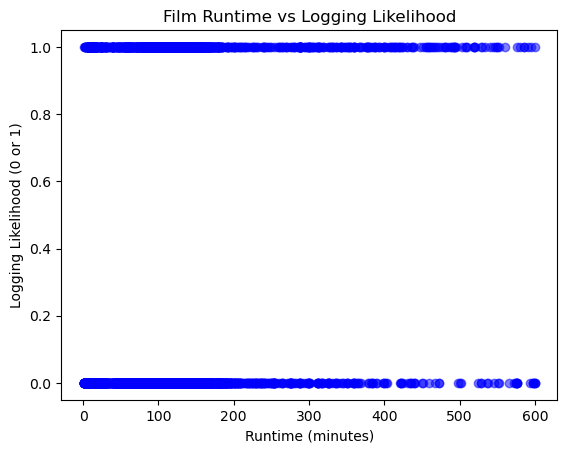

Training set size: (12996, 6)
Testing set size: (3250, 6)

 Model Performance
Lasso MSE:  0.1284, RMSE:  0.3584
Random Forest MSE: 0.0000, RMSE: 0.0000

Polynomial Regression Performance
Degree: 3
MSE: 0.0609
RMSE: 0.2467

Model Comparison Summary
Lasso RMSE:          0.3584
Random Forest RMSE:  0.0000
Polynomial RMSE:     0.2467


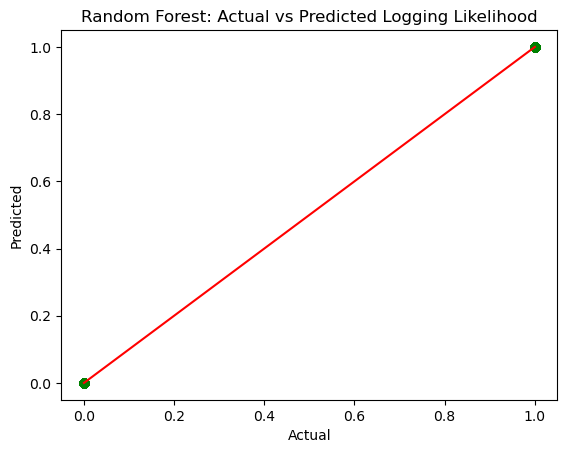


 Feature Importance (Random Forest)
               Feature  Importance
0                 year       0.515
1            age_years       0.485
2              runtime       0.000
3         title_length       0.000
4           word_count       0.000
5  title_runtime_ratio       0.000

New movie predictions (Random Forest):
[1. 0.]


In [6]:
"""
AI Revolutionary Coder (in-training): Xavier Harvey

Model Framework: Regression

For this project, I explore a dataset from Kaggle, based on the app, Letterboxd. This is an app used by film enthusiasts to perform a plethora of functions;
chief among them is logging movies that the user has watched. 

Goal: Predict the likelihood of a movie being logged, given parameters such as: duration, genre, release date, etc.

The continuous nature of this goal necessitates a regression aproach, as opposed to classification. 

This dataset doesn't contain the ideal target value (i.e. number of logs). Therefore, a proxy target is used: 'is_recent'.
I thought this was a sensible approach, since recent movies tend to be logged more often (as shown on the homepage of Letterboxd).
Perfect? No. Valid? Yes (hopefully). 

"""

## I. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import PolynomialFeatures # For polynomial Regression Model
from sklearn.linear_model import LinearRegression

# Handle missing numeric values (NaN)
from sklearn.impute import SimpleImputer

## II. Load dataset

# Source: https://www.kaggle.com/datasets/kutayahin/letterboxd-movies-dataset/data

df = pd.read_csv("letterboxd_movies_dataset.csv")

# Preview data
print(df.head())
print(df.info)

## III-a. Select features and targt value

# Target Variable: Likelihood of being logged (approximated by is_recent)
df['log_likelihood'] = df['is_recent'].astype(int)

# Select manual features to avoid manual hard coding
numeric_features = [
    "year", "age_years", "runtime", "title_length",
    "word_count", "title_runtime_ratio"
]

X = df[numeric_features]
y = df["log_likelihood"]

imputer = SimpleImputer(strategy = "median")
X = pd.DataFrame(imputer.fit_transform(X), columns = numeric_features)

print("\nSelected Features: \n", X.head())
print("\nTarget Variable: \n", y.head())

## III-b. Simple Exploration Plot: Runtime vs. Likelihood
plt.scatter(df["runtime"], y, color = 'blue', alpha = 0.5)
plt.xlabel("Runtime (minutes)")
plt.ylabel("Logging Likelihood (0 or 1)")
plt.title("Film Runtime vs Logging Likelihood")
plt.show()

## IV. Train, Test, and Split Data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

## V-a. Lasso Regression Model

"""
Regarding methods, I'll be using Lasso regression and random forest. 
Lasso regression adds an L1 penalty to model coefficients, cauding some coefficients to deplete to exactly zero. 
This means Lasso performs automatic feature selection. This is ideal, as overfitting is prevented, and modewl complexity is reduced. 
Additionally, the most pertinent movie features are identified.

"""
lasso_model = Lasso(alpha = 0.05)
lasso_model.fit(X_train, y_train)

## V-b. Random Forest Regression Model

"""
I chose Random Forest to be the latter regression model. Essentially, this is a ML model that constructs multiple decision trees (hence: forest).
Each tree is designed to extract patterns differently, with the forest averaging their predictions. 
Similarly to lasso, this method reduces overfitting. The key difference, however, is that random trees capture nonlinear relationships. 

"""

rf_model = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 6,
    random_state = 42
)

rf_model.fit(X_train, y_train)

## V-c. Polynomial Regression Model

"""
Polynomial Regression, simply put, is an extension of simple linear regression. 
Instead of fitting a straight line to the data, polynomial regression fits a curved line of a certain degree. 
This occurs by adding new features, such as: x, x^2, x^3, ..., x^d, to capture non-linear relationships. 
This method is significantly more flexible than standard linear regression, and ideal when data displays non-linear patterns, 
but a simple and interpretable model is desired. The main detriment is that if the degree is too high, the model is prone to overfitting. 

"""

# Choose polynomial degree
poly_degree = 3

# Transform original features into polynomial features
poly = PolynomialFeatures(degree = poly_degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Fit the model
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

# Predict
poly_pred = poly_model.predict(X_poly_test)

# Evaluate the model
poly_mse = mean_squared_error(y_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)

## VI-a. Predictions & Performance Comparison

lasso_pred = lasso_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Mean Squared Error (MSE)
lasso_mse = mean_squared_error(y_test, lasso_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

# Root Mean Squared Error (RMSE)
lasso_rmse = np.sqrt(lasso_mse)
rf_rmse = np.sqrt(rf_mse)

print("\n Model Performance")
print(f"Lasso MSE: {lasso_mse: .4f}, RMSE: {lasso_rmse: .4f}")
print(f"Random Forest MSE: {rf_mse:.4f}, RMSE: {rf_rmse:.4f}")

print("\nPolynomial Regression Performance")
print(f"Degree: {poly_degree}")
print(f"MSE: {poly_mse:.4f}")
print(f"RMSE: {poly_rmse:.4f}")

print("\nModel Comparison Summary")
print(f"Lasso RMSE:          {lasso_rmse:.4f}")
print(f"Random Forest RMSE:  {rf_rmse:.4f}")
print(f"Polynomial RMSE:     {poly_rmse:.4f}")


## VI-b. Plot Actual vs Predicted Outcomes (Random Forest)

plt.scatter(y_test, rf_pred, color = 'green')
plt.plot([0,1], [0,1], color = 'red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted Logging Likelihood")
plt.show()


## VII. Feature Significance (from Random Forest)
importances = pd.DataFrame({
    "Feature": numeric_features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending = False) # Most important feature is at the top

print("\n Feature Importance (Random Forest)")
print(importances)

## VIII. Test Model with new movie examples

new_movies = pd.DataFrame({
    "year": [2024, 1999],
    "age_years": [1, 26],
    "runtime": [120, 155],
    "title_length": [10, 12],
    "word_count": [2, 3],
    "title_runtime_ratio": [0.083, 0.077]
})

print("\nNew movie predictions (Random Forest):")
print(rf_model.predict(new_movies))